In [1]:
# Importing libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf


Returns all the variable created in the Notebook
 `%whos`

# Preparing data for the model

In [2]:
columns_names = ['unit_number', 'Operation_cycle','Operational_settings_1' , 'Operational_settings_2','Operational_settings_3']+[f'Sensor_measurement_{i}' for i in range(1,22)]
columns_names

['unit_number',
 'Operation_cycle',
 'Operational_settings_1',
 'Operational_settings_2',
 'Operational_settings_3',
 'Sensor_measurement_1',
 'Sensor_measurement_2',
 'Sensor_measurement_3',
 'Sensor_measurement_4',
 'Sensor_measurement_5',
 'Sensor_measurement_6',
 'Sensor_measurement_7',
 'Sensor_measurement_8',
 'Sensor_measurement_9',
 'Sensor_measurement_10',
 'Sensor_measurement_11',
 'Sensor_measurement_12',
 'Sensor_measurement_13',
 'Sensor_measurement_14',
 'Sensor_measurement_15',
 'Sensor_measurement_16',
 'Sensor_measurement_17',
 'Sensor_measurement_18',
 'Sensor_measurement_19',
 'Sensor_measurement_20',
 'Sensor_measurement_21']

In [3]:
df_train = pd.read_csv('\train_FD001.txt',sep='\s+',header = None,names = columns_names,dtype= float)
df_test = pd.read_csv('test_FD001.txt',sep='\s+',header = None,names = columns_names,dtype= float)
df_RUL = pd.read_csv('RUL_FD001.txt",sep='\s+''',header = None,names = ['RUL'],dtype= float)

In [4]:
df_train.head()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Operational_settings_3,Sensor_measurement_1,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_5,...,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_16,Sensor_measurement_17,Sensor_measurement_18,Sensor_measurement_19,Sensor_measurement_20,Sensor_measurement_21
0,1.0,1.0,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392.0,2388.0,100.0,39.06,23.4190
1,1.0,2.0,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392.0,2388.0,100.0,39.00,23.4236
2,1.0,3.0,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390.0,2388.0,100.0,38.95,23.3442
3,1.0,4.0,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392.0,2388.0,100.0,38.88,23.3739
4,1.0,5.0,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393.0,2388.0,100.0,38.90,23.4044


In [5]:
df_train.tail()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Operational_settings_3,Sensor_measurement_1,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_5,...,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_16,Sensor_measurement_17,Sensor_measurement_18,Sensor_measurement_19,Sensor_measurement_20,Sensor_measurement_21
20626,100.0,196.0,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397.0,2388.0,100.0,38.49,22.9735
20627,100.0,197.0,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395.0,2388.0,100.0,38.30,23.1594
20628,100.0,198.0,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398.0,2388.0,100.0,38.44,22.9333
20629,100.0,199.0,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395.0,2388.0,100.0,38.29,23.0640
20630,100.0,200.0,-0.0032,-0.0005,100.0,518.67,643.85,1600.38,1432.14,14.62,...,519.30,2388.26,8137.33,8.5036,0.03,396.0,2388.0,100.0,38.37,23.0522


In [6]:
df_test.head()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Operational_settings_3,Sensor_measurement_1,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_5,...,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_16,Sensor_measurement_17,Sensor_measurement_18,Sensor_measurement_19,Sensor_measurement_20,Sensor_measurement_21
0,1.0,1.0,0.0023,0.0003,100.0,518.67,643.02,1585.29,1398.21,14.62,...,521.72,2388.03,8125.55,8.4052,0.03,392.0,2388.0,100.0,38.86,23.3735
1,1.0,2.0,-0.0027,-0.0003,100.0,518.67,641.71,1588.45,1395.42,14.62,...,522.16,2388.06,8139.62,8.3803,0.03,393.0,2388.0,100.0,39.02,23.3916
2,1.0,3.0,0.0003,0.0001,100.0,518.67,642.46,1586.94,1401.34,14.62,...,521.97,2388.03,8130.10,8.4441,0.03,393.0,2388.0,100.0,39.08,23.4166
3,1.0,4.0,0.0042,0.0000,100.0,518.67,642.44,1584.12,1406.42,14.62,...,521.38,2388.05,8132.90,8.3917,0.03,391.0,2388.0,100.0,39.00,23.3737
4,1.0,5.0,0.0014,0.0000,100.0,518.67,642.51,1587.19,1401.92,14.62,...,522.15,2388.03,8129.54,8.4031,0.03,390.0,2388.0,100.0,38.99,23.4130


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   unit_number             20631 non-null  float64
 1   Operation_cycle         20631 non-null  float64
 2   Operational_settings_1  20631 non-null  float64
 3   Operational_settings_2  20631 non-null  float64
 4   Operational_settings_3  20631 non-null  float64
 5   Sensor_measurement_1    20631 non-null  float64
 6   Sensor_measurement_2    20631 non-null  float64
 7   Sensor_measurement_3    20631 non-null  float64
 8   Sensor_measurement_4    20631 non-null  float64
 9   Sensor_measurement_5    20631 non-null  float64
 10  Sensor_measurement_6    20631 non-null  float64
 11  Sensor_measurement_7    20631 non-null  float64
 12  Sensor_measurement_8    20631 non-null  float64
 13  Sensor_measurement_9    20631 non-null  float64
 14  Sensor_measurement_10   20631 non-null

In [8]:
df_train.shape

(20631, 26)

## Feature Selection

In [9]:
constant_sensors = []

for col in df_train.columns:
    if df_train[col].nunique() <=1:
        constant_sensors.append(col)

constant_sensors

['Operational_settings_3',
 'Sensor_measurement_1',
 'Sensor_measurement_5',
 'Sensor_measurement_10',
 'Sensor_measurement_16',
 'Sensor_measurement_18',
 'Sensor_measurement_19']

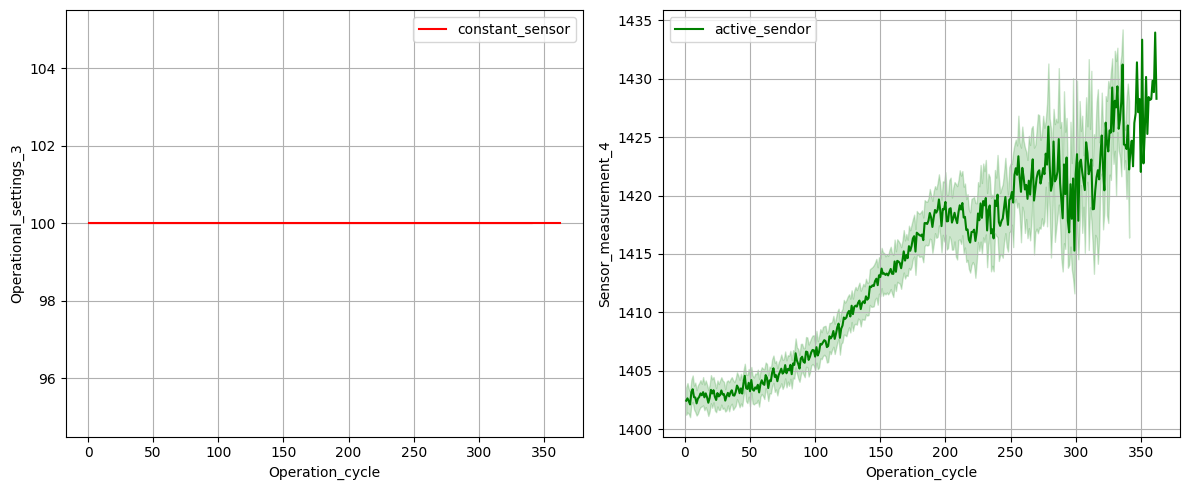

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.lineplot(x=df_train['Operation_cycle'], y=df_train['Operational_settings_3'], 
             data=df_train, ax=axes[0], color='r', label='constant_sensor')

sns.lineplot(x=df_train['Operation_cycle'], y=df_train['Sensor_measurement_4'], 
             data=df_train, ax=axes[1], color='g', label='active_sendor')

axes[0].legend()
axes[1].legend()

axes[0].grid()
axes[1].grid()

plt.tight_layout()
plt.savefig('sensor_image.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:
train_data = df_train.drop(constant_sensors,axis = 1 ).copy()
test_data = df_test.drop(constant_sensors,axis = 1 ).copy()

In [12]:
train_data.head()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_6,Sensor_measurement_7,Sensor_measurement_8,Sensor_measurement_9,Sensor_measurement_11,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_17,Sensor_measurement_20,Sensor_measurement_21
0,1.0,1.0,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1.0,2.0,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1.0,3.0,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1.0,4.0,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1.0,5.0,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044


In [13]:
test_data.head()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_6,Sensor_measurement_7,Sensor_measurement_8,Sensor_measurement_9,Sensor_measurement_11,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_17,Sensor_measurement_20,Sensor_measurement_21
0,1.0,1.0,0.0023,0.0003,643.02,1585.29,1398.21,21.61,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,8.4052,392.0,38.86,23.3735
1,1.0,2.0,-0.0027,-0.0003,641.71,1588.45,1395.42,21.61,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,8.3803,393.0,39.02,23.3916
2,1.0,3.0,0.0003,0.0001,642.46,1586.94,1401.34,21.61,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,8.4441,393.0,39.08,23.4166
3,1.0,4.0,0.0042,0.0000,642.44,1584.12,1406.42,21.61,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,8.3917,391.0,39.00,23.3737
4,1.0,5.0,0.0014,0.0000,642.51,1587.19,1401.92,21.61,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,8.4031,390.0,38.99,23.4130


## Feature Scaling (MinMaxScaler)

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

train_data.iloc[:, 2:] = scaler.fit_transform(train_data.iloc[:, 2:])
test_data.iloc[:, 2:]  = scaler.transform(test_data.iloc[:, 2:])


In [15]:
train_data.shape,test_data.shape


((20631, 19), (13096, 19))

In [16]:
train_data["RUL"] = None
test_data["RUL"] = None

In [17]:
default = (train_data.groupby(train_data['unit_number'])['Operation_cycle'].max().reset_index().rename(columns={"Operation_cycle":"Maximum_Cycle"}))
default.columns = ['unit_number','Maximum_cycle']
train_data = train_data.merge(default,on = "unit_number",  how='left')


default_test = (test_data.groupby(test_data['unit_number'])['Operation_cycle'].max().reset_index().rename(columns={"Operation_cycle":"Maximum_Cycle"}))
default_test.columns = ['unit_number','Maximum_cycle']
test_data = test_data.merge(default,on = "unit_number",  how='left')

In [18]:
default.head()

,unit_number,Maximum_cycle
0,1.0,192.0
1,2.0,287.0
2,3.0,179.0
3,4.0,189.0
4,5.0,269.0


In [19]:
train_data.tail()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_6,Sensor_measurement_7,Sensor_measurement_8,...,Sensor_measurement_11,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_17,Sensor_measurement_20,Sensor_measurement_21,RUL,Maximum_cycle
20626,100.0,196.0,0.477011,0.250000,0.686747,0.587312,0.782917,1.0,0.254428,0.439394,...,0.726190,0.170576,0.558824,0.194344,0.656791,0.750000,0.271318,0.109500,None,200.0
20627,100.0,197.0,0.408046,0.083333,0.701807,0.729453,0.866475,1.0,0.162641,0.500000,...,0.708333,0.211087,0.500000,0.188668,0.727203,0.583333,0.124031,0.366197,None,200.0
20628,100.0,198.0,0.522989,0.500000,0.665663,0.684979,0.775321,1.0,0.175523,0.515152,...,0.738095,0.281450,0.529412,0.212148,0.922278,0.833333,0.232558,0.053991,None,200.0
20629,100.0,199.0,0.436782,0.750000,0.608434,0.746021,0.747468,1.0,0.133655,0.530303,...,0.916667,0.208955,0.514706,0.203065,0.823394,0.583333,0.116279,0.234466,None,200.0
20630,100.0,200.0,0.316092,0.083333,0.795181,0.639634,0.842167,1.0,0.151369,0.545455,...,0.803571,0.130064,0.558824,0.192951,0.687572,0.666667,0.178295,0.218172,None,200.0


In [20]:
train_data['RUL'] = train_data["Maximum_cycle"]-train_data['Operation_cycle']

test_data['RUL'] = test_data["Maximum_cycle"]-test_data['Operation_cycle']

In [21]:
train_data.head()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_6,Sensor_measurement_7,Sensor_measurement_8,...,Sensor_measurement_11,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_17,Sensor_measurement_20,Sensor_measurement_21,RUL,Maximum_cycle
0,1.0,1.0,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,...,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191.0,192.0
1,1.0,2.0,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,...,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190.0,192.0
2,1.0,3.0,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,...,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189.0,192.0
3,1.0,4.0,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,...,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188.0,192.0
4,1.0,5.0,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,...,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187.0,192.0


In [22]:
train_data.drop('Maximum_cycle',axis = 1, inplace = True)
test_data.drop('Maximum_cycle',axis = 1, inplace = True)

In [23]:
train_data.head()

,unit_number,Operation_cycle,Operational_settings_1,Operational_settings_2,Sensor_measurement_2,Sensor_measurement_3,Sensor_measurement_4,Sensor_measurement_6,Sensor_measurement_7,Sensor_measurement_8,Sensor_measurement_9,Sensor_measurement_11,Sensor_measurement_12,Sensor_measurement_13,Sensor_measurement_14,Sensor_measurement_15,Sensor_measurement_17,Sensor_measurement_20,Sensor_measurement_21,RUL
0,1.0,1.0,0.459770,0.166667,0.183735,0.406802,0.309757,1.0,0.726248,0.242424,0.109755,0.369048,0.633262,0.205882,0.199608,0.363986,0.333333,0.713178,0.724662,191.0
1,1.0,2.0,0.609195,0.250000,0.283133,0.453019,0.352633,1.0,0.628019,0.212121,0.100242,0.380952,0.765458,0.279412,0.162813,0.411312,0.333333,0.666667,0.731014,190.0
2,1.0,3.0,0.252874,0.750000,0.343373,0.369523,0.370527,1.0,0.710145,0.272727,0.140043,0.250000,0.795309,0.220588,0.171793,0.357445,0.166667,0.627907,0.621375,189.0
3,1.0,4.0,0.540230,0.500000,0.343373,0.256159,0.331195,1.0,0.740741,0.318182,0.124518,0.166667,0.889126,0.294118,0.174889,0.166603,0.333333,0.573643,0.662386,188.0
4,1.0,5.0,0.390805,0.333333,0.349398,0.257467,0.404625,1.0,0.668277,0.242424,0.149960,0.255952,0.746269,0.235294,0.174734,0.402078,0.416667,0.589147,0.704502,187.0


In [24]:
RUL_Threshold = 130
train_data['RUL'] = train_data['RUL'].clip(upper=RUL_Threshold)

test_data["RUL"] = test_data['RUL'].clip(upper=RUL_Threshold)

In [25]:
train_data['RUL'].describe().T

count    20631.000000
mean        88.727304
std         43.444137
min          0.000000
25%         51.000000
50%        103.000000
75%        130.000000
max        130.000000
Name: RUL, dtype: float64

### Ploting the smoothned sensor data VS RUL to analyis the data tend when Engine reaches to it Predective maintenance 

In [26]:
def plot_sensor(data,sensor_name):

    if sensor_name not in data.columns:
        print(f'Please enter correct sensor name and enterned name is {sensor_name}')
        return
    
    plt.figure(figsize= (13,7))

    units_to_plot = [u for u in data['unit_number'].unique() if u%10==0]

    for unit in units_to_plot:
        unit_data = data[data['unit_number']== unit]
        smoothed_signal = unit_data[sensor_name].rolling(window = 15,center = True).mean()
        plt.plot(unit_data['RUL'], smoothed_signal, linewidth=2, alpha=0.6, label=f'Unit {unit}')

    plt.xlim(data['RUL'].max(), 0)
    plt.axvspan(30,0, color='red', alpha=0.1, label='Critical Zone (<30 Cycles)')

    plt.xlabel('Remaining Useful Life (RUL)', fontsize=12)
    plt.ylabel(f'{sensor_name} Value (Smoothed)', fontsize=12)
    
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show();
    



### Getting our test window ready 

In [27]:
WINDOW_SIZE = 7
HORIZON = 1  
feature_cols = [col for col in train_data.columns if col not in ['unit_number', 'RUL', 'Operation_cycle']]
#function for windowing 
def window_data(data,window_size = WINDOW_SIZE,horizon = HORIZON):
    
    X = []
    y = []
    
    for unit in data["unit_number"].unique():
        unit_df = data[data["unit_number"] == unit]
        unit_df = unit_df.sort_values("Operation_cycle")
    
        features = unit_df[feature_cols].values
        rul = unit_df["RUL"].values
    
        for i in range(len(unit_df) - window_size - horizon + 1):
            X.append(features[i:i + window_size])
            y.append(rul[i + window_size - 1]) 

    return np.array(X),np.array(y)
    

In [28]:
# Windoing our train_data and test_data
X_train,y_train = window_data(train_data,WINDOW_SIZE,HORIZON)

In [29]:
def make_test_sequences(data, window_size):
    X = []
    for unit in sorted(data["unit_number"].unique()):
        unit_df = data[data["unit_number"] == unit].sort_values("Operation_cycle")
        features = unit_df[feature_cols].values
        if len(features) >= window_size:
            X.append(features[-window_size:])      # last 7 cycles
        else:
            pad = np.zeros((window_size - len(features), len(feature_cols)))
            X.append(np.vstack([pad, features]))   # pad short engines
    return np.array(X)

X_test = make_test_sequences(test_data, WINDOW_SIZE)
y_test = df_RUL['RUL'].values   # ← use the file you already loaded!

In [30]:
def make_preds(model, input_data):
  """
  uses model to make predcition input_data.
  """

  forecast = model.predict(input_data)
  return tf.squeeze(forecast)

In [31]:
def mean_absolute_scaled_error(y_true,y_pred):
  """
  Implementing MASE for non-seasonal time series
  """

  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1]))

  return mae/mae_naive_no_season

In [32]:
def evaluate_preds(y_true, y_pred):
    y_true = tf.cast(y_true, dtype=tf.float32)
    y_pred = tf.cast(y_pred, dtype=tf.float32)

    mae  = tf.reduce_mean(tf.abs(y_true - y_pred))
    mse  = tf.reduce_mean(tf.square(y_true - y_pred))
    rmse = tf.sqrt(mse)
    mape = tf.reduce_mean(tf.abs((y_true - y_pred) / y_true)) * 100
    mase = mean_absolute_scaled_error(y_true, y_pred)

    if mae.ndim >1:
      mae = tf.reduce_mean(mae)
      mse = tf.reduce_mean(mse)
      rmse = tf.reduce_mean(rmse)
      mape= tf.reduce_mean(mape)
      mase = tf.reduce_mean(mase)


    return {"mae":  mae.numpy(),
            "mse":  mse.numpy(),
            "rmse": rmse.numpy(),
            "mape": mape.numpy(),
            "mase": mase.numpy()}

## LSTM with Window_size = 7 and Horizon = 1

In [33]:
## Building Time Series model (LSTM)
from tensorflow.keras import layers


inputs = layers.Input(shape=(WINDOW_SIZE, len(feature_cols)))
x = layers.LSTM(128, return_sequences=True)(inputs)       
x = layers.LSTM(64)(x)  
x = layers.Dense(64,activation='relu')(x)
outputs = layers.Dense(HORIZON)(x)

model_1 = tf.keras.Model(inputs,outputs,name = "model_1_LSTM")

model_1.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)
with tf.device('/GPU:0'):
    history_1 = model_1.fit(
        X_train, y_train,
        batch_size=128,
        epochs=150,
        validation_data=(X_test, y_test),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=10, verbose=1)
        ]
)

Epoch 1/150
156/156 [==============================] - 7s 14ms/step - loss: 4905.8940 - mae: 59.6339 - val_loss: 1757.5609 - val_mae: 36.1144 - lr: 0.0010
Epoch 2/150
156/156 [==============================] - 2s 10ms/step - loss: 1865.5459 - mae: 38.4783 - val_loss: 1892.7429 - val_mae: 35.9281 - lr: 0.0010
Epoch 3/150
156/156 [==============================] - 2s 11ms/step - loss: 1862.4806 - mae: 38.3569 - val_loss: 1916.7368 - val_mae: 35.9523 - lr: 0.0010
Epoch 4/150
156/156 [==============================] - 2s 11ms/step - loss: 1863.0979 - mae: 38.3467 - val_loss: 1890.0155 - val_mae: 35.9261 - lr: 0.0010
Epoch 5/150
156/156 [==============================] - 2s 10ms/step - loss: 1862.7529 - mae: 38.3436 - val_loss: 1891.7111 - val_mae: 35.9275 - lr: 0.0010
Epoch 6/150
156/156 [==============================] - 2s 10ms/step - loss: 1862.8022 - mae: 38.3551 - val_loss: 1867.7864 - val_mae: 35.9082 - lr: 0.0010
Epoch 7/150
156/156 [==============================] - 2s 10ms/step - 

Text(0.5, 23.52222222222222, 'epochs')

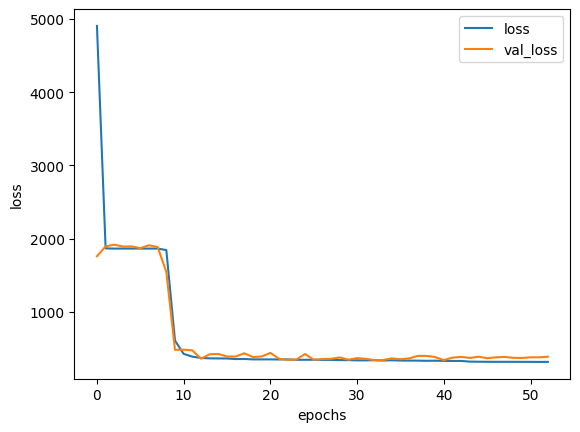

In [34]:
pd.DataFrame(history_1.history)[["loss","val_loss"]].plot();
plt.savefig('Window_7.png', dpi=300, bbox_inches='tight')
plt.ylabel('loss')
plt.xlabel('epochs')

In [35]:
model_1.summary()

Model: "model_1_LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 7, 17)]           0         
                                                                 
 lstm (LSTM)                 (None, 7, 128)            74752     
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dense (Dense)               (None, 64)                4160      
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 128,385
Trainable params: 128,385
Non-trainable params: 0
_________________________________________________________________


In [36]:
model_1_preds = make_preds(model_1,X_test)
model_1_results = evaluate_preds(y_test, y_pred = model_1_preds)
model_1_results

4/4 [==============================] - 1s 4ms/step


{'mae': 13.397884,
 'mse': 338.47043,
 'rmse': 18.397566,
 'mape': 23.459606,
 'mase': 0.29215652}

## LSTM with Window_size = 30 and Horizon = 1

In [37]:
WINDOW_SIZE = 30
HORIZON = 1  
feature_cols = [col for col in train_data.columns if col not in ['unit_number', 'RUL', 'Operation_cycle']]
#function for windowing 
def window_data(data,window_size = WINDOW_SIZE,horizon = HORIZON):
    
    X = []
    y = []
    
    for unit in data["unit_number"].unique():
        unit_df = data[data["unit_number"] == unit]
        unit_df = unit_df.sort_values("Operation_cycle")
    
        features = unit_df[feature_cols].values
        rul = unit_df["RUL"].values
    
        for i in range(len(unit_df) - window_size - horizon + 1):
            X.append(features[i:i + window_size])
            y.append(rul[i + window_size - 1]) 

    return np.array(X),np.array(y)

# Windowing our train_data and test_data
X_train,y_train = window_data(train_data,WINDOW_SIZE,HORIZON)
def make_test_sequences(data, window_size):
    X = []
    for unit in sorted(data["unit_number"].unique()):
        unit_df = data[data["unit_number"] == unit].sort_values("Operation_cycle")
        features = unit_df[feature_cols].values
        if len(features) >= window_size:
            X.append(features[-window_size:])      
        else:
            pad = np.zeros((window_size - len(features), len(feature_cols)))
            X.append(np.vstack([pad, features]))   
    return np.array(X)

X_test = make_test_sequences(test_data, WINDOW_SIZE)
y_test = df_RUL['RUL'].values   

## Building Time Series model (LSTM)
from tensorflow.keras import layers


inputs = layers.Input(shape=(WINDOW_SIZE, len(feature_cols)))
x = layers.LSTM(128, return_sequences=True)(inputs)       
x = layers.LSTM(64)(x)  
x = layers.Dense(64,activation='relu')(x)
outputs = layers.Dense(HORIZON)(x)

model_2 = tf.keras.Model(inputs,outputs,name = "model_2_LSTM")

model_2.compile(
    loss='mse',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['mae']
)
with tf.device('/GPU:0'):
    history_2 = model_2.fit(
        X_train, y_train,
        batch_size=128,
        epochs=150,
        validation_data=(X_test, y_test),
        callbacks=[
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=10, verbose=1)
        ]
)

Epoch 1/150
138/138 [==============================] - 5s 21ms/step - loss: 4284.8745 - mae: 54.8237 - val_loss: 1740.4233 - val_mae: 36.2999 - lr: 0.0010
Epoch 2/150
138/138 [==============================] - 2s 16ms/step - loss: 1852.9272 - mae: 38.1870 - val_loss: 1769.7809 - val_mae: 36.0153 - lr: 0.0010
Epoch 3/150
138/138 [==============================] - 2s 16ms/step - loss: 1851.9510 - mae: 38.1879 - val_loss: 1788.8510 - val_mae: 35.9443 - lr: 0.0010
Epoch 4/150
138/138 [==============================] - 2s 15ms/step - loss: 1851.7554 - mae: 38.1565 - val_loss: 1778.6047 - val_mae: 35.9772 - lr: 0.0010
Epoch 5/150
138/138 [==============================] - 2s 16ms/step - loss: 1852.3201 - mae: 38.1791 - val_loss: 1782.3069 - val_mae: 35.9619 - lr: 0.0010
Epoch 6/150
138/138 [==============================] - 2s 16ms/step - loss: 1852.1595 - mae: 38.1652 - val_loss: 1771.8940 - val_mae: 36.0062 - lr: 0.0010
Epoch 7/150
138/138 [==============================] - 2s 15ms/step - 

Text(0.5, 23.52222222222222, 'epochs')

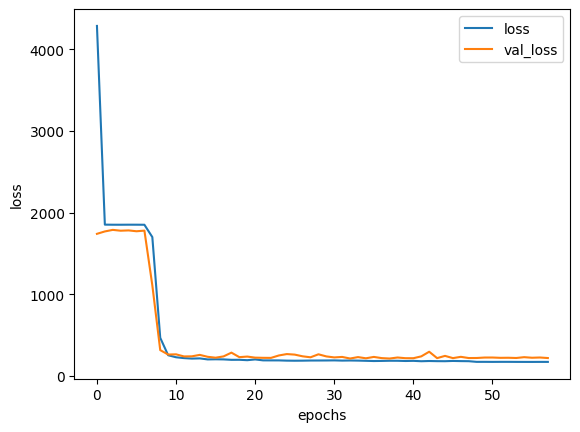

In [38]:
pd.DataFrame(history_2.history)[["loss","val_loss"]].plot();
plt.savefig('Window_30.png', dpi=300, bbox_inches='tight')
plt.ylabel('loss')
plt.xlabel('epochs')

In [39]:
# model_2.save("model/model_w30.h5")


In [40]:
# model_1.save("model/model_w7.h5")


In [41]:
# with open("scaler/scaler.pkl", "wb") as f:
#     pickle.dump(scaler, f)

In [42]:
model_2_preds = make_preds(model_2,X_test)
model_2_results = evaluate_preds(y_test, y_pred = model_2_preds)
model_2_results

4/4 [==============================] - 1s 6ms/step


{'mae': 10.68941,
 'mse': 214.4237,
 'rmse': 14.643213,
 'mape': 15.257753,
 'mase': 0.23309506}